## Methods of Machine Learning (MAT 3373 A00) Short Homework Assignment 1
### Alex Hills 300241757

In [64]:
# Python imports:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LinearRegression
import numpy as np

# Setting up the dataframes for SchoolA.csv, SchoolB.csv and SchoolC.csv
school_a = pd.read_csv("CSV_Files/SchoolA.csv", names=["IQ", "Diligence"], header=0)
school_b = pd.read_csv("CSV_Files/SchoolB.csv", names=["IQ", "Diligence"], header=0)
school_c = pd.read_csv("CSV_Files/SchoolC.csv", names=["IQ", "Diligence"], header=0)

***

## Part 1

(Copied from assignment description): Some psychologists would like to study the following (informal) question: does being smarter have an influence on diligence? They start to answer this question by defining some test that is intended to measure diligence, then getting all of the students at a university A to report both their IQ and their results on a diligence test. The data are in the file SchoolA.csv, with the first column corresponding to IQ.

We will fit this data to the standard linear regression model:  $Y_i = \beta_0 + \beta_1X_i + \epsilon_i$

where the $X_i$’s are IQ and the $Y_i$’s should be diligence

To answer this question:

1. Write down a hypothesis test for $\beta_1$ that corresponds to the informal question.
2. Fit the model and write down the results of the hypothesis test.
3. You should check if the residuals are (roughly) Gaussian. Display an appropriate plot, and
mention if they seem to be Gaussian based on the plot.

***

### 1.1: Hypothesis test for β1:  
Null Hypothesis: $H_0:\beta_1 = 0$  
Alt. Hypothesis: $H_1:\beta_1 \neq 0$

Where $H_0$ corresponds to there being no linear relationship between IQ scores and diligence, and $H_1$ being that there is some linear relationship, positive or negative.

Then the test-statistic is:  $t=\frac{\hat\beta_1}{SE(\hat\beta_1)}$  

Which we input into the student's t-distribution with $n-2$ degrees of freedom (in this case, $n\approx50000$) to get the p-value, however we will use Python to compute this value rather than computing by hand. 

### 1.2: Fitting the Model:

In [65]:
# Fitting the model (using sklearn)

x = school_a[["IQ"]]
y = school_a["Diligence"]
fit = LinearRegression()
fit.fit(x,y)

# Printing some relevant values (slope+intercept)
print("Slope (beta_1):",fit.coef_)
print("Intercept (beta_0):",fit.intercept_)

Slope (beta_1): [-0.5545756]
Intercept (beta_0): 173.42780332359126


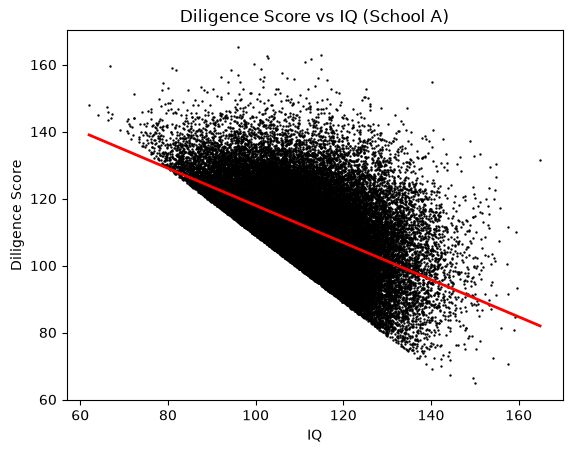

In [66]:
# Plotting the regression (I don't know if this was required but it was fun to do and a useful sanity check)

x_grid = pd.DataFrame({
    "IQ": np.linspace(x.iloc[:, 0].min(), x.iloc[:, 0].max(), 200)
})

plt.scatter(x["IQ"], y, s=0.5,color="black") # Draws the individual observations 
plt.plot(x_grid["IQ"], fit.predict(x_grid), color="red",linewidth=2) # Draws the fitted regression line
plt.xlabel("IQ")
plt.ylabel("Diligence Score")
plt.title("Diligence Score vs IQ (School A)")
plt.show()

In [67]:
# Calculating the p-value and determining the results of the hypothesis test (using scipy)

# by default, this is a two-tailed test with H0: beta_1 = 0, so there is nothing to change for our purposes
result_a = stats.linregress(school_a["IQ"], school_a["Diligence"]) 
t_stat = result_a.slope / result_a.stderr
print("t-stat:", t_stat)
print("p-value:", result_a.pvalue)

t-stat: -149.82644517462882
p-value: 0.0


#### Conclusion
Therefore there is very strong evidence ($p-value\ll0.05$) to suggest a linear relationship between IQ and diligence, enough to reject the null hypothesis (specifically a negative relationship, though our alternative hypothesis was only that there is some relationship, either positive or negative). 

Note: while the computed p-value above reads as 0.0, that does not literally mean a p-value of 0, only that the computed value is so small that SciPy returns it as such.

### 1.3: Plotting the residuals



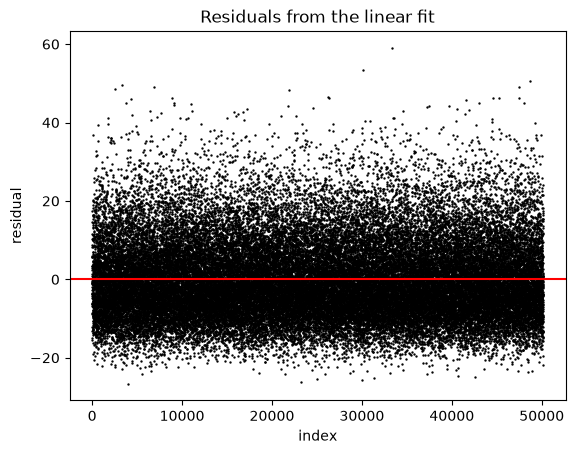

In [96]:
# Plotting the residuals

fitted_values = fit.predict(x)
residuals = y - fitted_values

plt.scatter(np.arange(len(residuals)), residuals, s=0.5, color="black")
plt.axhline(0, color="red")
plt.xlabel("index")
plt.ylabel("residual")
plt.title("Residuals from the linear fit")
plt.show()

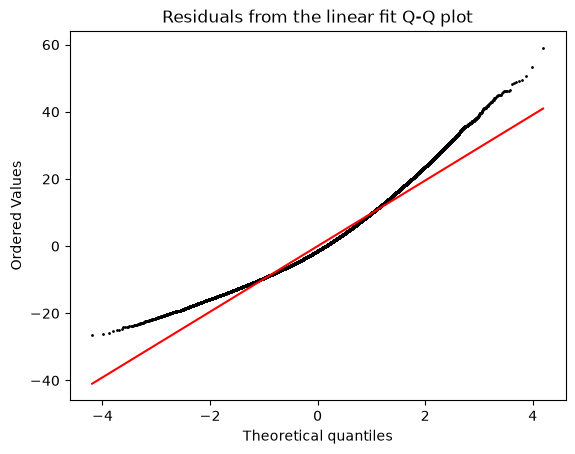

In [95]:
# Creating a Q-Q plot for the residuals. Not strictly necessary, but useful for this discussion

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Residuals from the linear fit Q-Q plot")

# Accesses scatter points component of the QQ-plot (just to customize them to match the design of my other plots haha)
points_line = plt.gca().get_lines()[0]  # index 0 is the scatter points
points_line.set_markeredgecolor('black')
points_line.set_markersize(1)

#### Conclusion

The residuals appear distinctly non-Gaussian, since they are not distributed symmetrically around zero, as seen in the residuals plot. Rather, there appears to be a strong positive-skewness, with the points above zero extending much further, as high as $+60$ above, compared to only about $-30$ below. 

This is compounded by the original plot, in which the data seems artificially truncated beneath some boundary below the trendline, and in the Q-Q plot of the residuals, in which the points are clearly curved upwards above the reference line, rather than following it linearly. 